# Title & Goals
- Analyzing resultant leg force and angle from the trials 
- speed as well
- If it works, could proceed to impact force and kinetic energy
- Sept 23rd: uploaded the required dataset and narrowed down to filtered FT data that matches the trials investigated for wingbeat frequency & amplitude 
- Sept 24th: follow the steps on FT_filtering & signal_processing to add butterworth filter. 

## 1. Only look at the trials that were filtered 

## libraries

In [9]:
import sys
sys.path.append('..')
import flight_ontogeny.helpers as helpers
import flight_ontogeny.helpers_BW as helpers_BW
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal as signal
from tqdm.notebook import  tqdm, tqdm_notebook

In [10]:
from importlib import reload 
reload(helpers)
reload(helpers_BW)

<module 'flight_ontogeny.helpers_BW' from 'C:\\Users\\jesu4036\\Documents\\flight-ontogeny\\src\\flight_ontogeny\\helpers_BW.py'>

## 1. Load the filtered raw data 

### 1.1 Load dataset
Load the **pre-processed & filtered** force/torque data into a pandas dataframe.
>The force/torques should have been calibrated (w.r.t time), zero-centered, and filtered (with a custom Butterworth filter). \
*See `FT_preprocessing.ipynb` and `FT_filtering.ipynb` notebooks*

In [4]:
path = "C:\\Users\\jesu4036\\Documents\\flight-ontogeny\\data\\takeoff\\FT_dataframe_subset_golden8_butterfilt.csv"
df = pd.read_csv(path, index_col=0,
                 dtype = {'FlightID': int, 'Bird': str, 'Age': int, 
                          'Landing': pd.Int64Dtype(), 'Note': str,'Frame': float, 
                          'Fx': float,'Fy': float,'Fz': float,'Tx': float,'Ty': float,'Tz': float})
df

#5932800 rows -> 4986048 rows for take-off. 

,FlightID,Bird,Age,Takeoff,Note,Frame,Fx,Fy,Fz,Tx,Ty,Tz,Time,Fx_filt,Fy_filt,Fz_filt,Tx_filt,Ty_filt,Tz_filt
0,2302001,cyanR-blackL,20,1,NaN,1.000,-0.132588,-0.022100,-0.003362,0.504721,-12.001989,0.426949,-2.000000,-0.133255,-0.022654,-0.003628,0.503325,-12.003724,0.423088
1,2302001,cyanR-blackL,20,1,NaN,1.125,-0.144294,-0.004517,-0.007162,0.251551,-12.140376,0.815985,-1.998958,-0.133998,-0.019021,-0.006011,0.478074,-12.052556,0.478702
2,2302001,cyanR-blackL,20,1,NaN,1.250,-0.142735,0.001155,-0.030686,0.368279,-12.361784,0.716373,-1.997917,-0.134740,-0.015489,-0.007900,0.451907,-12.099235,0.526876
3,2302001,cyanR-blackL,20,1,NaN,1.375,-0.110659,0.002457,-0.001084,0.595999,-12.434521,1.010667,-1.996875,-0.135465,-0.012142,-0.009058,0.424115,-12.142261,0.563668
4,2302001,cyanR-blackL,20,1,NaN,1.500,-0.148954,-0.001278,-0.044893,0.900303,-12.034076,0.725827,-1.995833,-0.136151,-0.009050,-0.009325,0.394202,-12.180422,0.586289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4986043,3110012,yellowR-purpleL,100,12,NaN,480.375,0.011364,0.003787,0.062098,0.302371,0.110241,-0.977764,1.994792,-0.000186,-0.002269,0.011146,0.001101,-0.008791,-0.143599
4986044,3110012,yellowR-purpleL,100,12,NaN,480.500,-0.019019,-0.001511,0.062350,0.012327,0.068579,-0.753798,1.995833,0.000093,-0.003693,0.009046,-0.004161,-0.020824,-0.142148
4986045,3110012,yellowR-purpleL,100,12,NaN,480.625,-0.001996,0.007695,0.025075,0.044156,0.072565,-0.265843,1.996875,0.000374,-0.005369,0.005509,-0.011154,-0.034852,-0.128933
4986046,3110012,yellowR-purpleL,100,12,NaN,480.750,0.002773,-0.015782,0.007049,-0.155048,0.076524,-0.086700,1.997917,0.000652,-0.007234,0.000784,-0.019532,-0.050307,-0.105604


### 1.2 Make a dataframe of individual flights
The goal is to have one data entry per flight; hence, we need to make a dataframe with one row for each flight.


In [5]:
flight_df = helpers_BW.make_flight_df(df)
flight_df #1043 rows 

,FlightID,Bird,Age,Takeoff
0,2302001,cyanR-blackL,20,1
1,2302002,cyanR-blackL,20,2
2,2302003,cyanR-blackL,20,3
3,2302401,cyanR-blackL,24,1
4,2302402,cyanR-blackL,24,2
...,...,...,...,...
1038,3110008,yellowR-purpleL,100,8
1039,3110009,yellowR-purpleL,100,9
1040,3110010,yellowR-purpleL,100,10
1041,3110011,yellowR-purpleL,100,11


## 2. Find the force of impact for each flight

We want to find the (maximum) force applied on the perch by the bird(s) upon impact; i.e., the force of the collision.

### 2.1 (take-off) Compute Fres

In [6]:
#make another column for resultant force

df['Ftotal_filt'] = np.sqrt(df['Fx_filt']**2+df['Fy_filt']**2+df['Fz_filt']**2)

### 2.2 (take-off) Review each flight
- The functions in helpers_BW.py are specific to landing frames. 
- Take-off frames for bodyweight and max force at take-off are expected to be different. 
    - I've already used Time instead of Frame to zero center the force plots. 
- Review 100 flights of 5 individuals (therefore 20 flights each) to determine if there are consistent patterns in the windows for bodyweight and max force. 

In [7]:
# from flight_df, randomly select 100 flights to review from 5 individuals (20 each)
selected_flights = flight_df.sample(n=120, random_state=1)
selected_flights['Bird'].unique()

array(['pinkR-blackL', 'greenR', 'greenR-purpleL', 'redR-purpleL',
       'pinkR-blueL', 'greenR-blueL', 'yellowL', 'yellowR-greyL',
       'greenR-greenL', 'purpleR-blackL', 'greenR-whiteL', 'cyanR-blackL',
       'redR-yellowL', 'greyR-blackL', 'yellowR-purpleL', 'redR-blackL',
       'greenR-orangeL'], dtype=object)

In [ ]:
selected_flights.shape

In [ ]:
selected_flights

In [ ]:
selected_flights['FlightID'].unique().shape

In [ ]:
#per Flight ID



In [ ]:
# show the plots of Fy for each flight in 4 columns, 40 rows.

fig, axs = plt.subplots(nrows=40, ncols=3, figsize=(15, 160))
axs = axs.flatten()

for i, flight in enumerate(selected_flights['FlightID'].unique()):
    flight_data = df[df['FlightID'] == flight]

    age = selected_flights[selected_flights['FlightID'] == flight]['Age'].values[0]
    bird = selected_flights[selected_flights['FlightID'] == flight]['Bird'].values[0]
    takeoff = selected_flights[selected_flights['FlightID'] == flight]['Takeoff'].values[0]

    time = flight_data['Time'].values
    Ftotal_filt = flight_data['Ftotal_filt'].values

    #detect plateaus and bodyweight  
    plateaus, bodyweight = helpers_BW.zbdetect_bw_Ftot(flight_data)

    #overlay 'Fz' by 'Time' in yellow line
    axs[i].plot(time, flight_data['Fz_filt'], label='Fz_filt', color='yellow')
    
    #overlay 'Fy' by 'Time' in blue line
    axs[i].plot(time, flight_data['Fy_filt'], label='Fy_filt')
    
    #overlay 'Fx' by 'Time'in orange line
    axs[i].plot(time, flight_data['Fx_filt'], label='Fx_filt', color='orange')
    
    #overlay 'Ftotal_filt'by 'Time' in pink line
    axs[i].plot(flight_data['Time'], flight_data['Ftotal_filt'], label='Ftotal_filt', color='pink')
   
    # Highlight plateau regions in yellow
    for start_idx, end_idx in plateaus:
        axs[i].axvspan(time[start_idx], time[end_idx], color='yellow', alpha=0.3)

    # Plot bodyweight as horizontal dashed line
    if not np.isnan(bodyweight):
        axs[i].axhline(y=bodyweight, color='grey', linestyle='--', label='Bodyweight')
    
    #axs[i].axhline(y=helpers_BW.get_bodyweight(df, flight, use_filt=True), color='r', linestyle='--', label='Bodyweight')
    # Show bird, age, takeoff in title
    axs[i].set_title(f'FlightID: {flight}_{bird}, Age: {age}, Trial: {takeoff}')
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('F (N)')
    axs[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
#draw the same graph but 0.5 second before and after Fy maximum point 
#(Fx minimum point can be a finch placing event)
fig, axs = plt.subplots(nrows=40, ncols=3, figsize=(15, 160))
axs = axs.flatten()

for i, flight in enumerate(selected_flights['FlightID'].unique()):
    flight_data = df[df['FlightID'] == flight]

    # Skip if Fy_filt is all NaN or empty
    if flight_data['Fy_filt'].dropna().empty:
        print(f"Skipping FlightID {flight} — Fy_filt is empty or all NaN.")
        continue

    age = selected_flights[selected_flights['FlightID'] == flight]['Age'].values[0]
    bird = selected_flights[selected_flights['FlightID'] == flight]['Bird'].values[0]
    takeoff = selected_flights[selected_flights['FlightID'] == flight]['Takeoff'].values[0]

    # Find the time of maximum Fy
    max_Fy_time = flight_data.loc[flight_data['Fy_filt'].idxmax(), 'Time']

    # Define the time window
    time_window = (flight_data['Time'] >= max_Fy_time - 0.5) & (flight_data['Time'] <= max_Fy_time + 0.5)
    windowed_data = flight_data[time_window]

    axs[i].plot(windowed_data['Time'], windowed_data['Fy_filt'], label='Fy_filt')
    axs[i].plot(windowed_data['Time'], windowed_data['Fx_filt'], label='Fx_filt', color='orange')
    axs[i].set_title(f'FlightID: {flight}, Bird: {bird}, Age: {age}, Takeoff: {takeoff}')
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('F (N)')
    axs[i].legend()

#### Some comments by Kyu Min
- would be good to extract bodyweight with variance threshold (test the one used for shed tits). If I used time window, the window would be very small (<0.2 seconds before peak)
- use Fy peak to define the peak timing, ...or try overlaying F resultant force to see if it would be better. Then could just use F resultant for both bodyweight and peak. 

In [ ]:
selected_flights.shape

### 2.3. load hand-selected flights 

- refer to ZB_takeoff_FT_flight_by_flight to see the flights that were filtered/dumped

In [ ]:
path = "C:\\Users\\kmh\\Documents\\DATA\\zebras_2025\\df_all_chunks_edited_final.csv"
df = pd.read_csv(path, index_col=0)


In [ ]:
print(df.head(10))
print(df.shape) #4575324
print(df.dtypes)


In [ ]:
print(df['FlightID'].nunique()) #1004 flights only 39 flights out of 1043 filtered = 3.7 % 

In [ ]:
df.head(10)

## 3. maxF, bw & angle calculation
- 1. use get_force to calculate 'max_Ftot', 'time_max_Ftot',  'Fx_maxFtot', 'Fy_maxFtot', 'Fz_maxFtot', 'angle', 'bodyweight'
- 2. fill in the 'bodyweight' as the average of other trials at same age 
- 3. compare with the measured bodyweight on a scale abs(bodyweight - measured_bodyweight) and see if the difference is below 1 gram (0.001 N)  If so, use bodyweight and only add scale 
weight when left as NA. 
- 4. once bodyweight is filled on all the force data rows, merge bodyweight to df by 'FlightID'
- 5. calculate impulse and impulse duration using get_impulse()
- 6. merge impulse and impulse duration to force dataset using 'FlightID'

#### 3.1 get_force()

In [11]:
force_df = helpers_BW.get_force(df)

Processing groups:   0%|          | 0/1043 [00:00<?, ?it/s]

C:\Users\jesu4036\Documents\flight-ontogeny\src\flight_ontogeny\helpers_BW.py:519: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  # Append the new row to the force_outcome DataFrame
c:\Users\jesu4036\Documents\flight-ontogeny\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jesu4036\Documents\flight-ontogeny\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\jesu4036\Documents\flight-ontogeny\src\flight_ontogeny\helpers_BW.py:483: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecat

KeyError: nan

In [ ]:
force_df

#### 3.2 fill in bw

In [ ]:
force_df.to_csv('C:\\Users\\kmh\\Documents\\DATA\\zebras_2025\\force_df.csv')

In [14]:
force_df = pd.read_csv('C:\\Users\\jesu4036\\Desktop\\zebra-finches-fly\\zebras_2025\\force_df.csv', index_col = 0)

In [15]:
# find the rows where 'bodyweight' column in nan
bw_missing = force_df[force_df['bodyweight'].isna()]
bw_missing.shape #17 flights 

(17, 12)

In [16]:
bw_missing.head(5)

,FlightID,Bird,Age,Takeoff,max_Ftot,time_max_Ftot,Fx_maxFtot,Fy_maxFtot,Fz_maxFtot,angle,bodyweight,bw_avrgd
48,1208005.0,greyR-blackL,80,5,0.794646,0.2645833333333333,-0.43036676,0.6558196428268084,0.127070028,-33.27397929,NaN,0
75,1303201.0,pinkR-blackL,32,1,0.942448,0,-0.829676984,0.4142831862432153,0.1679681524897867,-63.46563565,NaN,0
148,1404002.0,pinkR-blueL,40,2,0.407142,11.021875,-0.199756511,0.2785802172117614,0.2196710410653635,-35.64249214,NaN,0
149,1404003.0,pinkR-blueL,40,3,0.414075,11.18125,-0.053492726,0.3975015867075126,0.1029018128596035,-7.664382878,NaN,0
150,1404004.0,pinkR-blueL,40,4,0.734073,5.6,-0.490282192,0.5033862270442028,0.2123397084495699,-44.24445383,NaN,0


In [17]:
force_df['bw_avrgd'] = 0 
bw_missing = force_df[force_df['bodyweight'].isna()]
print(bw_missing)
    
for i, row in bw_missing.iterrows():
        # Filter rows for the same bird and age (other trials)
        other_trials_rows = force_df[(force_df['Bird'] == row['Bird']) & (force_df['Age'] == row['Age'])]
        print(other_trials_rows)
        # Calculate the average of non-NaN bodyweight values 
        avg_bodyweight = other_trials_rows['bodyweight'].dropna().mean()

        # Replace the NaN value with the average if available
        if not np.isnan(avg_bodyweight):
            force_df.loc[i, 'bodyweight'] = avg_bodyweight
            force_df.loc[i, 'bw_avrgd'] = 1 



      FlightID             Bird  Age  Takeoff  max_Ftot       time_max_Ftot  \
48   1208005.0     greyR-blackL   80        5  0.794646  0.2645833333333333   
75   1303201.0     pinkR-blackL   32        1  0.942448                   0   
148  1404002.0      pinkR-blueL   40        2  0.407142           11.021875   
149  1404003.0      pinkR-blueL   40        3  0.414075            11.18125   
150  1404004.0      pinkR-blueL   40        4  0.734073                 5.6   
155  1406004.0      pinkR-blueL   60        4  0.775006  0.3791666666666666   
157  1406006.0      pinkR-blueL   60        6  0.757851  0.4083333333333333   
159  1406008.0      pinkR-blueL   60        8  0.790718  0.2447916666666666   
360  2602003.0   greenR-purpleL   20        3  0.691975        -0.036458333   
363  2602006.0   greenR-purpleL   20        6  0.813790             0.01875   
376  2603201.0   greenR-purpleL   32        1  0.932884            2.990625   
378  2603203.0   greenR-purpleL   32        3  0.752

In [ ]:
force_df[force_df['bodyweight'].isna()]

In [ ]:
force_df.to_csv('C:\\Users\\kmh\\Documents\\DATA\\zebras_2025\\force_df_filled.csv')

#### 3.3 check with measured bodyweight

In [18]:
bw_measured = pd.read_csv('C:\\Users\\jesu4036\\Desktop\\zebra-finches-fly\\zebras_2025\\bodyweight_measured.csv', index_col =0)

In [ ]:
bw_measured

In [19]:
force_df.head(5)

,FlightID,Bird,Age,Takeoff,max_Ftot,time_max_Ftot,Fx_maxFtot,Fy_maxFtot,Fz_maxFtot,angle,bodyweight,bw_avrgd
0,1202001.0,greyR-blackL,20,1,0.749694,0.028125,-0.636484365,0.3878547414768175,0.080606078,-58.64310635,0.176742,0
1,1202002.0,greyR-blackL,20,2,0.684754,0.05625,-0.572184754,0.3758210670126501,0.015847747,-56.70238298,0.168647,0
2,1202003.0,greyR-blackL,20,3,0.757987,0.034375,-0.694875514,0.2977708496719198,0.054993227,-66.80370427,0.170129,0
3,1202004.0,greyR-blackL,20,4,0.695034,0.033333333,-0.539956536,0.4371585595784888,-0.020283803,-51.00574404,0.186426,0
4,1202402.0,greyR-blackL,24,2,0.818428,0.016666667,-0.593472219,0.5635616592524929,0.003659716,-46.48082719,0.152715,0


In [20]:
# merge bodyweight_measured to force_df by columns 'Bird' and 'Age'
force_bw_df = force_df.merge(bw_measured, on=['Bird', 'Age'], how='left')


In [21]:
# changing to newtons for bodyweight_measured
force_bw_df['bodyweight_measured'] = force_bw_df['bodyweight_measured'] *0.001*9.80665

In [22]:
force_bw_df.head(10)

,FlightID,Bird,Age,Takeoff,max_Ftot,time_max_Ftot,Fx_maxFtot,Fy_maxFtot,Fz_maxFtot,angle,bodyweight,bw_avrgd,bodyweight_measured
0,1202001.0,greyR-blackL,20,1,0.749694,0.028125,-0.636484365,0.3878547414768175,0.080606078,-58.64310635,0.176742,0,0.133370
1,1202002.0,greyR-blackL,20,2,0.684754,0.05625,-0.572184754,0.3758210670126501,0.015847747,-56.70238298,0.168647,0,0.133370
2,1202003.0,greyR-blackL,20,3,0.757987,0.034375,-0.694875514,0.2977708496719198,0.054993227,-66.80370427,0.170129,0,0.133370
3,1202004.0,greyR-blackL,20,4,0.695034,0.033333333,-0.539956536,0.4371585595784888,-0.020283803,-51.00574404,0.186426,0,0.133370
4,1202402.0,greyR-blackL,24,2,0.818428,0.016666667,-0.593472219,0.5635616592524929,0.003659716,-46.48082719,0.152715,0,0.139254
5,1202403.0,greyR-blackL,24,3,0.864962,0.023958333,-0.661951338,0.5566236852337281,0.012254629,-49.94008829,0.158581,0,0.139254
6,1202404.0,greyR-blackL,24,4,0.861268,0.0125,-0.677294698,0.4839145604386545,-0.221090585,-54.45489334,0.160777,0,0.139254
7,1202405.0,greyR-blackL,24,5,0.914568,0.023958333,-0.724738221,0.5383232970770201,0.1462747674931422,-53.3956593,0.167268,0,0.139254
8,1202801.0,greyR-blackL,28,1,0.900371,0.020833333,-0.686468319,0.5763314826113733,0.085268547,-49.98451785,0.189277,0,0.153964
9,1202802.0,greyR-blackL,28,2,1.030587,-0.008333333,-0.915902745,0.2925053707510068,-0.371041225,-72.28844613,0.200713,0,0.153964


In [27]:
force_bw_df['FlightID'].nunique()

1004

In [23]:
# calculate mean and standard deviation of the difference between 'bodyweight' and 'bodyweight_measured'
# Calculate the difference
diff = abs(force_bw_df['bodyweight'] - force_bw_df['bodyweight_measured'])

# Compute mean and standard deviation
mean_diff = diff.mean()
std_diff = diff.std()

print("Mean difference:", mean_diff)
print("Standard deviation of difference:", std_diff)

print("Mean difference (in g):", mean_diff *1000/9.80665)
print("Standard deviation of difference (in g):", std_diff*1000/9.80665)


Mean difference: 0.006896902637938443
Standard deviation of difference: 0.011300423495376735
Mean difference (in g): 0.7032883439236073
Standard deviation of difference (in g): 1.1523225051752368


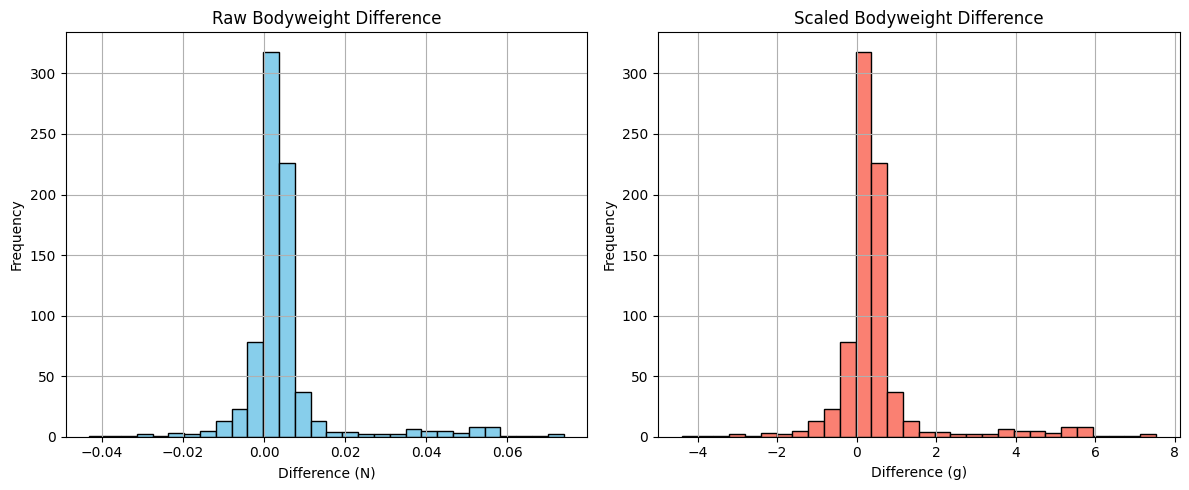

In [24]:
# Calculate the difference and scaled difference
diff = force_bw_df['bodyweight'] - force_bw_df['bodyweight_measured']
diff = diff.dropna()
scaled_diff = diff * 1000 / 9.80665

# Create side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw difference histogram
axes[0].hist(diff, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Raw Bodyweight Difference')
axes[0].set_xlabel('Difference (N)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True)

# Scaled difference histogram
axes[1].hist(scaled_diff, bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Scaled Bodyweight Difference')
axes[1].set_xlabel('Difference (g)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### comments
- the mean difference between the measured bw and sensor bw is below 1g. 
- but in some cases the difference is up to 7g. 
- the measured bodyweight may be more accurate to actual bodyweight, but the sensor bodyweight would be more accurate to the weight that was on the perch before take-off. 
- the bodyweight on the sensor is more closely related to the take-off force. 
-> check the trials where the bodyweight difference between the perch and the scale was more than 1 g. (chose 1g as this maximum 10 % difference of bodyweight )

#### 3.4 check trials with diff > 0.01 N 

In [25]:
force_bw_df['diff_g'] = (force_bw_df['bodyweight'] - force_bw_df['bodyweight_measured'])*1000 / 9.80665

In [26]:
over_diff = force_bw_df[force_bw_df['diff_g'] >= 1.0]
print(over_diff.shape)
print(over_diff.head(5))

(78, 14)
    FlightID          Bird  Age  Takeoff  max_Ftot time_max_Ftot  \
0  1202001.0  greyR-blackL   20        1  0.749694      0.028125   
1  1202002.0  greyR-blackL   20        2  0.684754       0.05625   
2  1202003.0  greyR-blackL   20        3  0.757987      0.034375   
3  1202004.0  greyR-blackL   20        4  0.695034   0.033333333   
4  1202402.0  greyR-blackL   24        2  0.818428   0.016666667   

     Fx_maxFtot          Fy_maxFtot    Fz_maxFtot         angle  bodyweight  \
0  -0.636484365  0.3878547414768175   0.080606078  -58.64310635    0.176742   
1  -0.572184754  0.3758210670126501   0.015847747  -56.70238298    0.168647   
2  -0.694875514  0.2977708496719198   0.054993227  -66.80370427    0.170129   
3  -0.539956536  0.4371585595784888  -0.020283803  -51.00574404    0.186426   
4  -0.593472219  0.5635616592524929   0.003659716  -46.48082719    0.152715   

   bw_avrgd  bodyweight_measured    diff_g  
0         0             0.133370  4.422697  
1         0      

In [ ]:
helpers_BW.plot_flight_data(over_diff, df)

## 4. Impulse function
- the graphs all look alright. I think I'll have to stick with the perch measured one. 
- merge df (filtered force logs) with bodyweight by 'FlightID' -> df_bw
- run get_impulse

In [ ]:
df.dtypes

In [ ]:
print(df.head(5))
print(force_bw_df.head(5))

- okay, starting again. Before I calculate impulse. I just have to make sure if 0.11 seconds centrered around the peak still works for zebra finches as they did for blue tits 

In [ ]:
# Step 1: Select relevant columns and drop duplicates
flight_df_unique = df[['FlightID', 'Bird', 'Age', 'Takeoff']].drop_duplicates()

# Step 2: Randomly sample 100 rows
flight_df_sampled = flight_df_unique.sample(n=100, random_state=17)
flight_df_sampled2 = flight_df_unique.sample(n=100, random_state = 35)
# Step 3: Ensure it's a DataFrame with the desired columns
flight_df_sampled = pd.DataFrame(flight_df_sampled, columns=['FlightID', 'Bird', 'Age', 'Takeoff']).reset_index()
flight_df_sampled2 = pd.DataFrame(flight_df_sampled2, columns=['FlightID', 'Bird', 'Age', 'Takeoff']).reset_index()

flight_df_sampled = flight_df_sampled.drop(columns='index')
flight_df_sampled2 = flight_df_sampled2.drop(columns='index')


flight_df_sampled.head(10)

In [ ]:
df.dtypes

In [ ]:
df.head(5)

In [ ]:
bodyweight = force_bw_df[['FlightID', 'bodyweight']]

In [ ]:
bodyweight = force_bw_df[['FlightID', 'bodyweight']]
df_bw = pd.merge(df, bodyweight, on = 'FlightID', how = 'left')

#### 4.1 plot_flight_peaks()

- find the longest positive continuous interval that includes the peak
- question: when to start measuring impulse? 
-- problem: zebra finches take off with less "dip" before take-off than blue tits, so Ftotal_filt can be positive for a little amount for a long time. 
- first, see if just find the longest positive continuous interval that includes the peak can successfully identify the impulse region. 
- if not control the interval area 

In [ ]:
df_bw.head(10)

### plots - impulse marked

In [ ]:
helpers_BW.plot_flight_peaks(flight_df_sampled2, df_bw, interval=0.35)

##### compute_impulse()

In [ ]:
impulse_df = helpers_BW.compute_impulse(df_bw) #11.8s

In [ ]:
impulse_df

#### 4.2 Histogram of impulse

In [ ]:
# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(impulse_df['impulse'], bins=30, color='mediumseagreen', edgecolor='black')
plt.xlabel('Impulse (N·s)')
plt.ylabel('Frequency')
plt.title('Histogram of Impulse Values')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.3 MERGE!

In [ ]:
force_final = force_bw_df.merge(impulse_df, on = 'FlightID', how = 'left')
force_final

#### 4.4 SAVE

In [ ]:
force_final.to_csv('C:\\Users\\kmh\\Documents\\DATA\\zebras_2025\\force_final.csv')

In [ ]:
#not using this for takeoff as it specifies specific landing window
flight_df['Impact Fx'] = [helpers_BW.find_max_force(df, i, "Fx", use_filt=True) for i in  (flight_df['FlightID'])]

Next, to find the maximum force regardless of the direction, we need a new variable:
> The euclidean norm of the  $F_{x}$ and  $F_{x}$ components, named  $F_{xy}$. \
$|F_{xy}|=\sqrt{F_x^{^2} + F_y^{^2} }.$

In [ ]:
df = helpers_BW.compute_Fxy(df)

Now, we can compute the maximum force applied in all the directions we're interested in: $F_{x}$, $F_{x}$, $F_{xy}$ (total), as well as the torque $T_{z}$:

In [ ]:
for col in tqdm(["Fxy", "Fx", "Fy", "Tz"]):
    flight_df['Impact '+col] = [helpers_BW.find_max_force(df, i, col, use_filt=True) for i in  (flight_df['FlightID'])]
    helpers_BW.plot_impactVSbw(flight_df, col)
    plt.show()

- lots of minimal values. 

## Everything below is by Emma 
### 3.2 Get bird bodyweight for each flight
To be able to see changes in impact force across time, we need to scale it by the bodyweight of the bird at the time of landing (since the weight changes with age and can fluctuate within days).
> To do this, we need to compute the bodyweight of the bird when it's a rest on the perch (after landing). We use a custom function for this called `get_bodyweight` (in `helpers_BW.py`). 

We can later verify that the bodyweight computed is correct by matching it with the recorded bird mass recorded using the digital scale (only on certain days).  

In [ ]:
#get_bodyweight also focused on specific frame. 
flight_df['BW (perch)'] = [helpers_BW.get_bodyweight(df, i, use_filt=True) for i in (flight_df['FlightID'])]
flight_df

Since the bodyweight might be inaccurate (I cannot believe the she-hulk yellowR-purpleL is 10 g... ), I will also bring manual values with scale. 

In [ ]:
path = "C:\\Users\\kmh\\Documents\\ZF_flight_ontogeny\\data\\takeoff\\bodyweight.csv"
BW_scale = pd.read_csv(path,
                 dtype = {'Bird': str, 'Age': int, 'BW_g':float})

In [ ]:
BW_scale['BW_N'] = BW_scale['BW_g'] * 0.001 * 9.80665
BW_scale

In [ ]:
#merge by Bird and Age 
BW_scale.columns

In [ ]:
# Merge DataFrames A and B by 'Bird' and 'Age', keeping all from A
flight_df_merged = flight_df.merge(BW_scale, on=['Bird', 'Age'], how='left')

# Print the merged DataFrame
print(flight_df_merged)

#### Normalise by adult weight

To be able to compare growth curves between birds, we need to normalise the curve by the "adult" (or final) weight.

In [ ]:
#BW_norm = ?
 # average weight from age 40 to 100?


#### Histogram
We can then look at the distribution of (computed) bodyweight across the whole dataset.

In [ ]:
fig = plt.figure(figsize = (10, 6))
flight_df_merged['BW_N'].hist(bins=16,alpha=0.7, label='Bodyweight')
plt.xlabel("Fx = downward force (N)")
plt.ylabel("Count")
plt.legend()
plt.show()


Plot the distribution of the (max) force of impact for all flights alongside the BW:

In [ ]:
helpers_BW.plot_impactVSbw(flight_df_merged, "Fx")
flight_df_merged['BW_N'].hist(bins=10,alpha=0.7, label='Bodyweight')
plt.legend()
plt.show()

In [ ]:
# comparewith Fy and sqrt(Fx2+Fy2)

### 3.3 Relative force of impact
Now that we have the max force of impact and the (estimated) bodyweight for each flight, we can look at the relationship between the two variables
>Plot the force of impact __with respect to BW__:

#### landing

In [ ]:
fig = plt.figure(figsize = (10, 6))

sns.scatterplot(x="BW (perch)",
                y="Impact Fx",
                hue="Bird",
                alpha = 0.5,
                data=flight_df)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

#### takeoff
- seems that bodyweight has less impact on take-off force than it does on landing.

In [ ]:
fig = plt.figure(figsize = (10, 6))

sns.scatterplot(x="BW_N",
                y="Impact Fx",
                hue="Bird",
                alpha = 0.5,
                data=flight_df_merged)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

>Birds form clusters as expected since basal BW varies between individuals.

Because we want to be able to compare the force of impact accross the birds, we create a new variable: 

#### Force of impact __relative to bodyweight__
Now that we have the max force of impact and the (estimated) bodyweight for each flight, we can compute the relative force of impact (i.e. the force of impact scaled by bodyweight).

In [ ]:
flight_df_merged['Impact Fx (relative)'] = flight_df_merged['Impact Fx']/flight_df_merged['BW_N']
flight_df_merged['Impact Fy (relative)'] = flight_df_merged['Impact Fy']/flight_df_merged['BW_N']
flight_df_merged['Impact Fxy (relative)'] = flight_df_merged['Impact Fxy']/flight_df_merged['BW_N']
flight_df_merged['Impact Tz (relative)'] = flight_df_merged['Impact Tz']/flight_df_merged['BW_N']

We plot the relative force of impact for each bird (across all ages) to see if it is consistent across individuals:

In [ ]:
PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}

fig = plt.figure(figsize = (10, 6))

ax = sns.boxplot(y='Bird', x='Impact Fx (relative)', data=flight_df_merged,color="White",**PROPS, linewidth=0.75)
ax = sns.stripplot(y='Bird', x='Impact Fx (relative)', hue="Bird", size=3, data=flight_df_merged, alpha=0.85)


plt.xlim(xmin=0, xmax=7)
plt.xlabel("Impact Fx (relative to BW)")
plt.ylabel("Bird")
plt.legend('',frameon=False)
plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 6))

ax = sns.boxplot(y='Bird', x='Impact Fy (relative)', data=flight_df_merged, color="White",**PROPS, linewidth=0.75)
#ax = sns.swarmplot(y='Bird', x='Impact force (relative)', hue="Bird", size=3, data=flight_df, alpha=0.7)
ax = sns.stripplot(y='Bird', x='Impact Fy (relative)', hue="Bird",size=3, data=flight_df_merged, alpha=0.85)


plt.xlim(xmin=0)
plt.xlabel("Impact Fy (relative to BW)")
plt.ylabel("Bird")
plt.legend('',frameon=False)
plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 6))

ax = sns.boxplot(y='Bird', x='Impact Fxy (relative)', data=flight_df_merged, color="White",**PROPS, linewidth=0.75)
#ax = sns.swarmplot(y='Bird', x='Impact force (relative)', hue="Bird", size=3, data=flight_df, alpha=0.7)
ax = sns.stripplot(y='Bird', x='Impact Fxy (relative)', hue="Bird", size=3, data=flight_df_merged, alpha=0.85)

#plt.xlim(xmin=0, xmax=7)
plt.xlabel("Impact Fxy (relative)")
plt.ylabel("Bird")
plt.legend('',frameon=False)
plt.tight_layout()
#plt.savefig(r"D:\python_output\force_figures\boxplots_Fxy_bybird.png", dpi=300)
plt.show()

## 4. Forces over Time
Next, we want to look at how the variables computed above (BW, Impact force, relative impact force) change over time, as the bird gets older.

### 4.1 Growth curves (BW)
First we look at the change of bodyweight over time for each bird (individual growth curves)

In [ ]:
fig = plt.figure(figsize = (10, 6))

sns.lineplot(x='Age', y='BW_N', hue='Bird', style='Bird',
             ci='sd', linestyle='',markers=['o','o','o','o','o','o','o','o',],
             dashes=False, data=flight_df_merged)
#sns.pointplot(x='Age', y='BW (perch)',  hue='Bird', ci=None, data=flight_df)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.ylim(0.1, 0.25)
plt.ylabel("Bodyweight (N)")
#plt.savefig(r"D:\python_output\force_figures\lineplot_BW_bybird.png", dpi=300)

plt.show()

### 4.2 Impact force over time
Then, we look at how the relative impact forces (w.r.t. BW) change over time.

In [ ]:
colours = [ "#009E73", "#E69F00", "#0072B2",'#CC79A7']
labels = ["Vertical force", "Horizontal force", "Total force (norm)", "torque"]


for i, col in enumerate(["Fx", "Fy", "Fxy","Tz",]): #, ]
    fig = plt.figure(figsize = (10, 6))


    sns.pointplot(x="Age",
                    y="Impact " +col+" (relative)",
                    color = colours[i],
                    label = col,
                    alpha = 1,
                    data=flight_df_merged)
    #plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.title(col+" vs Age - All birds")
    plt.show()

The plots above have a non-linear axis and interpolation between datapoints.

### No interpolation
Replot the data, this time without interpolation and a linear time x axis

In [ ]:
for i, col in enumerate(["Fx", "Fy", "Fxy"]): #'Tz',

    fig2 = plt.figure(figsize = (8, 5))
    sns.lineplot(x="Age",
                    y="Impact " +col+" (relative)",
                    color = colours[i],
                    label = labels[i],
                    alpha = 1,
                     marker='o', 
                    linestyle='',
                    err_style='bars',
                    data=flight_df_merged)
    plt.legend(bbox_to_anchor=(0.75, 0.95), loc=2, borderaxespad=0.)
    plt.tight_layout()
    plt.ylim(0.5, 5)
    plt.ylabel("Impact force (BW)")
    plt.xlabel("Age (days)")
    #plt.savefig(r"D:\python_output\force_figures\pointplot_"+col+"_allbirds.png", dpi=300)
    
    plt.show()
    

### 4.3 Impact force over time __by individuals__ 

In [ ]:

g = sns.FacetGrid(flight_df_merged, col="Bird", hue='Bird', col_wrap=4, height=3, aspect=1.5)
g.map_dataframe(sns.lineplot, x="Age", y="Impact Fxy (relative)")
plt.tight_layout()
plt.ylabel("Impact F_norm (N)")
#plt.savefig(r"D:\python_output\force_figures\lineplot_impactforce_bybird.png", dpi=300)

plt.show()



### Curve fitting

21-02-2023: Asked Graham how to fit a curve/model on the time data - look up growth curve fit methods, with asymptotic behaviour. Need to find best fit that matches assumptions. To do later.\
7-03-2023: Use logistic fit?

In [ ]:
# Import curve fitting package from scipy
from scipy.optimize import curve_fit

def func(x, a, b, c):
    #return a * np.exp(-b * x) + c
    return a * (x-17) ** c  / ((x-17) ** c + b)
    #return a * np.log(b * x) + c
    #return a * np.exp(-b * x) + c

popt, pcov = curve_fit(func, flight_df.Age, flight_df['Impact Fx (relative)'], p0=[2.6, 5.2, 6.])
plt.figure()
plt.plot(flight_df.Age, flight_df['Impact Fx (relative)'], 'ko', label="Original Noised Data", alpha=0.05)
plt.plot(x, func(x, *popt), 'r-', label="Fitted Curve")
plt.legend()
plt.show()

## 5. Angle of impact

We can compute the angle of impact using `arctan` with Fx and Fy

In [ ]:
flight_df_merged['Impact angle'] = np.rad2deg(np.arctan2(flight_df_merged['Impact Fx'], flight_df_merged['Impact Fy']))

In [ ]:
angle_median = np.median(flight_df_merged['Impact angle'])
angle_std = np.std(flight_df_merged['Impact angle'])
print("Considering all the flights, the median of the angle of impact is ", 
      str(int(angle_median)), 
      "deg and the std deviation is ",
      str(int(angle_std)),
      "deg.")

### 5.1 Distribution of impact angle
#### Polar histogram

In [ ]:
def plot_polar_hist(degree_array, rticks):
    radians = np.deg2rad(degree_array)

    bin_size = 5
    a , b = np.histogram(degree_array, bins=np.arange(0, 360+bin_size, bin_size))
    centers = np.deg2rad(np.ediff1d(b)//2 + b[:-1])

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='polar')
    ax.bar(centers, a, width=np.deg2rad(bin_size), bottom=0.0, color='#A7C7E7', edgecolor='k')
    ax.set_rticks(rticks)  # Less radial ticks
    ax.set_rlabel_position(80)  # Move radial labels away from plotted line
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    plt.tight_layout()
    #plt.savefig(r"D:\python_output\force_figures\polar_histogram_landing_angle.png", dpi=300)
    plt.show()


In [ ]:
plot_polar_hist(flight_df_merged['Impact angle'], [0, 100])

##### Compare first vs last flights

In [ ]:
only_day20less = flight_df[flight_df['Age']<=20]
plot_polar_hist(only_day20less['Impact angle'], [0, 20, 40, 60])

In [ ]:
only_day60plus = flight_df[flight_df['Age']>=60]
plot_polar_hist(only_day60plus['Impact angle'], [0, 20, 40, 60])

#### Split between individuals

In [ ]:
fig = plt.figure(figsize = (10, 6))

ax = sns.boxplot(y='Bird', x='Impact angle', data=flight_df_merged, color="White",**PROPS, linewidth=0.75)
#ax = sns.swarmplot(y='Bird', x='Impact force (relative)', hue="Bird", size=3, data=flight_df, alpha=0.7)
ax = sns.stripplot(y='Bird', x='Impact angle', hue="Bird", size=3, data=flight_df_merged, alpha=0.85)

plt.xlabel("Impact angle (°)")
plt.ylabel("Bird")
plt.legend('',frameon=False)
plt.tight_layout()
#plt.savefig(r"D:\python_output\force_figures\boxplots_impactangle_bybird.png", dpi=300)
plt.show()

### 5.2 Angle of impact __over time__

In [ ]:

fig2 = plt.figure(figsize = (10, 6))
sns.lineplot(x="Age",
            y="Impact angle",
            alpha = 1,
            color = 'blue',
            marker='o', 
            linestyle='',
            label = 'all birds',
            err_style='bars',
            data=flight_df_merged)
plt.legend(bbox_to_anchor=(0.85, 0.95), loc=2, borderaxespad=0.)
plt.ylabel("Angle of impact on perch (°)")
plt.xlabel('Age (days)')
#plt.savefig(r"D:\python_output\force_figures\pointplot_impactangle_allbirds.png", dpi=300)

plt.show()

### 5.3 Angle of impact over time __by individuals__

In [ ]:

g = sns.FacetGrid(flight_df_merged, col="Bird", hue='Bird', col_wrap=4, height=3, aspect=1.5)
g.map_dataframe(sns.lineplot, x="Age", y="Impact angle")
g.set(ylim=(20, 70))

plt.ylabel("Angle of impact on perch (°)")

#plt.savefig(r"D:\python_output\force_figures\lineplot_impactangle_bybird.png", dpi=300)

plt.show()


## 6. Boolean masks: categorise bird states

In [ ]:
def find_stable_point(df, start_frame=240, window_size=10, tolerance=0.1, plot=False):    
    BW = helpers_BW.get_bodyweight(df)

    # Set the range of values to search for
    lower_range = - (BW + BW*tolerance)
    upper_range = - (BW - BW*tolerance)

    # Find the first N consecutive frames where the value stays within the given range
    consecutive_rows = window_size*8
    
    after_landing_df = df[df.Frame > 240]

    # create a boolean mask indicating whether the sample output is within the desired range
    mask = (after_landing_df['Fx_filt'] >= lower_range) & (after_landing_df['Fx_filt'] <= upper_range)

    # find the first index of the first sequence of N consecutive True values in the mask
    consecutive_true_indices = (mask.rolling(consecutive_rows).sum() == consecutive_rows).idxmax()

    output_frame = after_landing_df.loc[consecutive_true_indices]['Frame']
    
    if plot:
        g = sns.FacetGrid(df, row="Landing", height=6, aspect=1.5)
        g.map(sns.lineplot, "Frame", 'Fx_filt', label='filtered Fx', color='black')
        g.map(plt.axhline, y=lower_range, ls='--', c='blue')
        g.map(plt.axhline, y=upper_range, ls='--', c='blue')
        g.map(plt.axvline, x=output_frame, ls='--', c='red')
        g.map(plt.axvline, x=output_frame+10, ls='--', c='red')
        g.fig.suptitle("Flight ID = "+str(df.FlightID.unique()[0]))
        plt.legend(loc='upper right')
        plt.tight_layout()
    
    return(output_frame)

In [ ]:
sub_df = df[df['FlightID']==3210012]
find_stable_point(sub_df, tolerance=0.1, plot=True)